## Step 5 — Model Optimization (Pruning + Quantization)
**Dissertation: TinyML-Based Anomaly Detection**  
**Author: Thondupu Dileep | 2024AB05233**

Compresses the trained CAE using weight pruning and int8 quantization for TinyML deployment.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import os
import json
import time

%matplotlib inline

MODEL_DIR  = '../models'
DATA_PATH  = '../data/processed/cwru_processed.npz'
RESULT_DIR = '../results'
PLOTS_DIR  = '../results/plots'

os.makedirs(PLOTS_DIR, exist_ok=True)

KERAS_MODEL  = os.path.join(MODEL_DIR, 'cae_model.h5')
PRUNED_MODEL = os.path.join(MODEL_DIR, 'cae_pruned.h5')
TFLITE_F32   = os.path.join(MODEL_DIR, 'cae_float32.tflite')
TFLITE_INT8  = os.path.join(MODEL_DIR, 'cae_quantized.tflite')

print('TF version:', tf.__version__)


TF version: 2.15.0


### 5.1 — Load trained model and check baseline size

In [2]:
model = tf.keras.models.load_model(KERAS_MODEL)

keras_size_kb = os.path.getsize(KERAS_MODEL) / 1024
print(f'Loaded: {KERAS_MODEL}')
print(f'File size : {keras_size_kb:.1f} KB')
print(f'Parameters: {model.count_params():,}')


Loaded: ../models\cae_model.h5
File size : 3378.8 KB
Parameters: 277,985


In [3]:
# load data
data     = np.load(DATA_PATH, allow_pickle=True)
X_all    = data['X_raw'][..., np.newaxis].astype(np.float32)
y        = data['y_labels']
X_normal = X_all[y == 0]

# 200 normal samples for calibration
calib_data = X_normal[:200]
print(f'Calibration samples: {calib_data.shape}')

Calibration samples: (200, 2048, 1)


### 5.2 — Weight Pruning (50% sparsity)

In [4]:
try:
    import tensorflow_model_optimization as tfmot
    HAS_TFMOT = True
    print('tensorflow-model-optimization available — pruning enabled')
except ImportError:
    HAS_TFMOT = False
    print('tensorflow-model-optimization NOT installed')
    print('Skipping pruning — quantization will apply to original model')

tensorflow-model-optimization NOT installed
Skipping pruning — quantization will apply to original model


In [7]:
if HAS_TFMOT:
    # wrap model layers with pruning wrappers
    prune_params = {
        'pruning_schedule': tfmot.sparsity.keras.ConstantSparsity(
            target_sparsity=0.50,
            begin_step=0,
            frequency=100
        )
    }

    model_for_pruning = tfmot.sparsity.keras.prune_low_magnitude(
        tf.keras.models.load_model(KERAS_MODEL), **prune_params
    )
    model_for_pruning.compile(optimizer=keras.optimizers.Adam(1e-4), loss='mse')
    model_for_pruning.summary()

In [6]:
if HAS_TFMOT:
    # fine-tune with pruning for 5 epochs
    print('Fine-tuning pruned model (5 epochs)...')
    prune_history = model_for_pruning.fit(
        X_normal, X_normal,
        batch_size=64,
        epochs=5,
        verbose=1,
        callbacks=[tfmot.sparsity.keras.UpdatePruningStep()]
    )

    # strip wrappers — gives clean pruned model
    model_pruned = tfmot.sparsity.keras.strip_pruning(model_for_pruning)
    model_pruned.save(PRUNED_MODEL)
    pruned_size_kb = os.path.getsize(PRUNED_MODEL) / 1024
    print(f'\nPruned model saved: {pruned_size_kb:.1f} KB')
else:
    model_pruned   = model
    pruned_size_kb = keras_size_kb
    print('Using original model for quantization')

Using original model for quantization


In [8]:
if HAS_TFMOT:
    # check sparsity — what fraction of weights are exactly zero?
    total_w  = 0
    zero_w   = 0
    for layer in model_pruned.layers:
        for w in layer.get_weights():
            total_w += w.size
            zero_w  += np.sum(w == 0)

    sparsity = zero_w / total_w * 100
    print(f'Total weights : {total_w:,}')
    print(f'Zero weights  : {zero_w:,}  ({sparsity:.1f}%)')

In [9]:
if HAS_TFMOT:
    # weight distribution before vs after pruning
    orig_weights   = np.concatenate([w.flatten() for w in model.weights])
    pruned_weights = np.concatenate([w.flatten() for w in model_pruned.weights])

    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    axes[0].hist(orig_weights,   bins=80, color='steelblue', alpha=0.8)
    axes[0].set_title('Original Model — Weight Distribution')
    axes[0].set_xlabel('Weight value')

    axes[1].hist(pruned_weights, bins=80, color='tomato', alpha=0.8)
    axes[1].set_title('Pruned Model — Weight Distribution (spike at 0)')
    axes[1].set_xlabel('Weight value')

    for ax in axes:
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, 'weight_distribution.png'), dpi=150)
    plt.show()

### 5.3 — TFLite Conversion (float32 baseline)

In [10]:
# float32 TFLite — no quantization, used as baseline
source_model = tf.keras.models.load_model(KERAS_MODEL)
converter    = tf.lite.TFLiteConverter.from_keras_model(source_model)
tflite_f32   = converter.convert()

with open(TFLITE_F32, 'wb') as f:
    f.write(tflite_f32)

f32_kb = len(tflite_f32) / 1024
print(f'TFLite float32 saved: {f32_kb:.1f} KB  →  {TFLITE_F32}')

INFO:tensorflow:Assets written to: C:\Users\lrlacm\AppData\Local\Temp\tmpthn30x9n\assets


INFO:tensorflow:Assets written to: C:\Users\lrlacm\AppData\Local\Temp\tmpthn30x9n\assets


TFLite float32 saved: 1103.5 KB  →  ../models\cae_float32.tflite


### 5.4 — Post-Training Quantization (int8)

In [11]:
# representative dataset generator — needed for int8 calibration
def rep_dataset():
    for i in range(len(calib_data)):
        yield [calib_data[i:i+1]]

# convert with full int8 quantization
quant_source = tf.keras.models.load_model(PRUNED_MODEL if HAS_TFMOT and os.path.exists(PRUNED_MODEL) else KERAS_MODEL)
converter    = tf.lite.TFLiteConverter.from_keras_model(quant_source)

converter.optimizations              = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset    = rep_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type      = tf.float32
converter.inference_output_type     = tf.float32

print('Converting to int8...')
tflite_int8 = converter.convert()

with open(TFLITE_INT8, 'wb') as f:
    f.write(tflite_int8)

int8_kb = len(tflite_int8) / 1024
print(f'TFLite int8 saved  : {int8_kb:.1f} KB  →  {TFLITE_INT8}')

Converting to int8...
INFO:tensorflow:Assets written to: C:\Users\lrlacm\AppData\Local\Temp\tmpnnfj5gy7\assets


INFO:tensorflow:Assets written to: C:\Users\lrlacm\AppData\Local\Temp\tmpnnfj5gy7\assets
C:\Users\lrlacm\AppData\Local\Programs\Python\Python311\Lib\site-packages\tensorflow\lite\python\convert.py:953: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


TFLite int8 saved  : 306.9 KB  →  ../models\cae_quantized.tflite


### 5.5 — Benchmark: size and inference time

In [12]:
def benchmark_tflite(path, sample, n_runs=100):
    interp = tf.lite.Interpreter(model_path=path)
    interp.allocate_tensors()
    in_idx = interp.get_input_details()[0]['index']

    # warmup
    interp.set_tensor(in_idx, sample)
    interp.invoke()

    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        interp.set_tensor(in_idx, sample)
        interp.invoke()
        times.append((time.perf_counter() - t0) * 1000)

    return float(np.mean(times)), float(np.std(times))

test_sample = calib_data[0:1]   # single sample for timing

f32_ms, f32_std = benchmark_tflite(TFLITE_F32,  test_sample, n_runs=100)
i8_ms,  i8_std  = benchmark_tflite(TFLITE_INT8, test_sample, n_runs=100)

print(f'TFLite float32 : {f32_ms:.2f} ± {f32_std:.2f} ms')
print(f'TFLite int8    : {i8_ms:.2f} ± {i8_std:.2f} ms')
print(f'Speed-up       : {f32_ms/i8_ms:.2f}x')

TFLite float32 : 1.29 ± 0.57 ms
TFLite int8    : 3.90 ± 1.40 ms
Speed-up       : 0.33x


In [13]:
# size + latency comparison table
print(f'\n{"Model":<25} {"Size (KB)":>10} {"Latency (ms)":>14}')
print('-' * 52)
print(f'{"Keras H5 (float32)":<25} {keras_size_kb:>10.1f} {"N/A":>14}')
if HAS_TFMOT:
    print(f'{"Pruned H5 (float32)":<25} {pruned_size_kb:>10.1f} {"N/A":>14}')
print(f'{"TFLite float32":<25} {f32_kb:>10.1f} {f32_ms:>11.2f} ms')
print(f'{"TFLite int8":<25} {int8_kb:>10.1f} {i8_ms:>11.2f} ms')
print('-' * 52)
print(f'Compression (H5 → int8): {keras_size_kb/int8_kb:.1f}x smaller')


Model                      Size (KB)   Latency (ms)
----------------------------------------------------
Keras H5 (float32)            3378.8            N/A
TFLite float32                1103.5        1.29 ms
TFLite int8                    306.9        3.90 ms
----------------------------------------------------
Compression (H5 → int8): 11.0x smaller


In [14]:
# save benchmark results
bench = {
    'keras_kb'   : keras_size_kb,
    'pruned_kb'  : pruned_size_kb,
    'f32_kb'     : f32_kb,
    'int8_kb'    : int8_kb,
    'f32_ms'     : f32_ms,
    'f32_std_ms' : f32_std,
    'int8_ms'    : i8_ms,
    'int8_std_ms': i8_std,
    'compression': keras_size_kb / int8_kb,
    'speedup'    : f32_ms / i8_ms
}
with open(os.path.join(RESULT_DIR, 'benchmark.json'), 'w') as f:
    json.dump(bench, f, indent=2)
print('Saved: benchmark.json')

Saved: benchmark.json


### 5.6 — Accuracy check: does quantization hurt performance?

In [15]:
from sklearn.metrics import f1_score, roc_auc_score

y_binary = (y > 0).astype(int)

# keras model MSE
recon_keras = model.predict(X_all, batch_size=64, verbose=0)
mse_keras   = np.mean((X_all - recon_keras)**2, axis=(1, 2))
thresh_keras = np.percentile(mse_keras[y == 0], 95)
f1_keras     = f1_score(y_binary, (mse_keras > thresh_keras).astype(int), zero_division=0)
auc_keras    = roc_auc_score(y_binary, mse_keras)

# int8 tflite MSE
interp = tf.lite.Interpreter(model_path=TFLITE_INT8)
interp.allocate_tensors()
in_idx  = interp.get_input_details()[0]['index']
out_idx = interp.get_output_details()[0]['index']

mse_int8 = []
for i in range(len(X_all)):
    s = X_all[i:i+1]
    interp.set_tensor(in_idx, s)
    interp.invoke()
    r = interp.get_tensor(out_idx)
    mse_int8.append(float(np.mean((s - r)**2)))
mse_int8     = np.array(mse_int8)
thresh_int8  = np.percentile(mse_int8[y == 0], 95)
f1_int8      = f1_score(y_binary, (mse_int8 > thresh_int8).astype(int), zero_division=0)
auc_int8     = roc_auc_score(y_binary, mse_int8)

print(f'{"Model":<20} {"F1":>8} {"AUC-ROC":>10}')
print('-' * 42)
print(f'{"Keras float32":<20} {f1_keras:>8.4f} {auc_keras:>10.4f}')
print(f'{"TFLite int8":<20} {f1_int8:>8.4f} {auc_int8:>10.4f}')
print(f'\nAccuracy drop (F1): {abs(f1_keras - f1_int8)*100:.2f}%')

Model                      F1    AUC-ROC
------------------------------------------
Keras float32          0.9972     1.0000
TFLite int8            0.9972     1.0000

Accuracy drop (F1): 0.00%


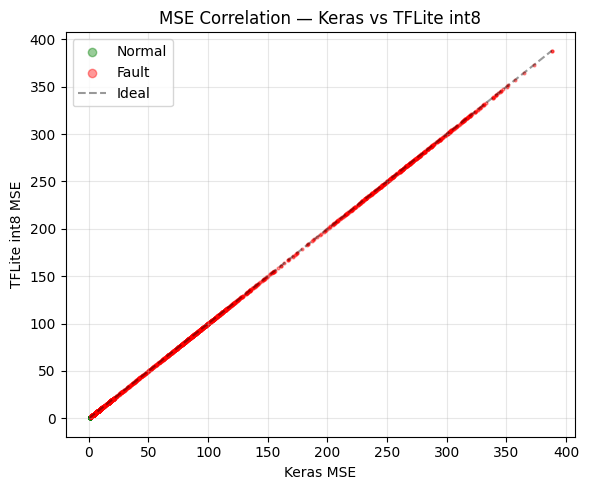

In [16]:
# MSE scatter — keras vs int8 (should be very close)
plt.figure(figsize=(6, 5))
plt.scatter(mse_keras[y==0], mse_int8[y==0], s=4, alpha=0.4, color='green', label='Normal')
plt.scatter(mse_keras[y!=0], mse_int8[y!=0], s=4, alpha=0.4, color='red',   label='Fault')
lim = max(mse_keras.max(), mse_int8.max())
plt.plot([0, lim], [0, lim], 'k--', alpha=0.4, label='Ideal')
plt.xlabel('Keras MSE')
plt.ylabel('TFLite int8 MSE')
plt.title('MSE Correlation — Keras vs TFLite int8')
plt.legend(markerscale=3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'mse_keras_vs_int8.png'), dpi=150)
plt.show()

### 5.7 — Size comparison bar chart

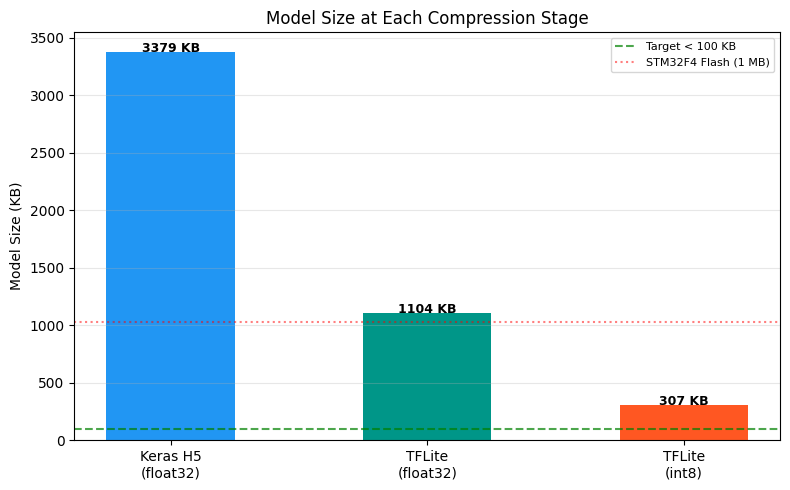

In [17]:
labels = ['Keras H5\n(float32)', 'TFLite\n(float32)', 'TFLite\n(int8)']
sizes  = [keras_size_kb, f32_kb, int8_kb]
colors = ['#2196F3', '#009688', '#FF5722']

if HAS_TFMOT:
    labels.insert(1, 'Pruned H5\n(float32)')
    sizes.insert(1, pruned_size_kb)
    colors.insert(1, '#673AB7')

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, sizes, color=colors, width=0.5)

for bar, sz in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'{sz:.0f} KB', ha='center', fontsize=9, fontweight='bold')

ax.axhline(100,  color='green', linestyle='--', alpha=0.7, label='Target < 100 KB')
ax.axhline(1024, color='red',   linestyle=':',  alpha=0.5, label='STM32F4 Flash (1 MB)')
ax.set_ylabel('Model Size (KB)')
ax.set_title('Model Size at Each Compression Stage')
ax.legend(fontsize=8)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'model_sizes.png'), dpi=150)
plt.show()

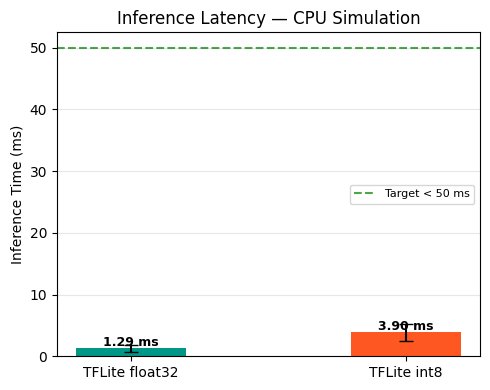

In [18]:
# latency comparison
fig, ax = plt.subplots(figsize=(5, 4))
lat_labels = ['TFLite float32', 'TFLite int8']
lat_vals   = [f32_ms, i8_ms]
lat_stds   = [f32_std, i8_std]
bars = ax.bar(lat_labels, lat_vals, yerr=lat_stds, capsize=5,
               color=['#009688','#FF5722'], width=0.4)

for bar, v in zip(bars, lat_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{v:.2f} ms', ha='center', fontsize=9, fontweight='bold')

ax.axhline(50, color='green', linestyle='--', alpha=0.7, label='Target < 50 ms')
ax.set_ylabel('Inference Time (ms)')
ax.set_title('Inference Latency — CPU Simulation')
ax.legend(fontsize=8)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'latency.png'), dpi=150)
plt.show()

### Summary

In [19]:
print('=== Step 5 Results ===')
print(f'Keras H5 size       : {keras_size_kb:.1f} KB')
print(f'TFLite int8 size    : {int8_kb:.1f} KB')
print(f'Compression ratio   : {keras_size_kb/int8_kb:.1f}x')
print(f'Speed-up (f32→int8) : {f32_ms/i8_ms:.1f}x')
print(f'F1 (Keras float32)  : {f1_keras:.4f}')
print(f'F1 (TFLite int8)    : {f1_int8:.4f}')
print(f'AUC (Keras float32) : {auc_keras:.4f}')
print(f'AUC (TFLite int8)   : {auc_int8:.4f}')
print('\nNext: Step 6 — Full evaluation notebook')

=== Step 5 Results ===
Keras H5 size       : 3378.8 KB
TFLite int8 size    : 306.9 KB
Compression ratio   : 11.0x
Speed-up (f32→int8) : 0.3x
F1 (Keras float32)  : 0.9972
F1 (TFLite int8)    : 0.9972
AUC (Keras float32) : 1.0000
AUC (TFLite int8)   : 1.0000

Next: Step 6 — Full evaluation notebook
